In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

MOVING OBJECT

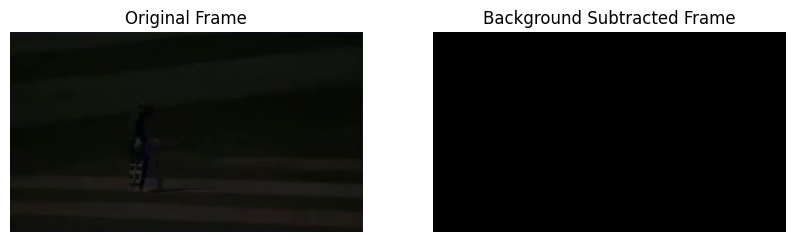

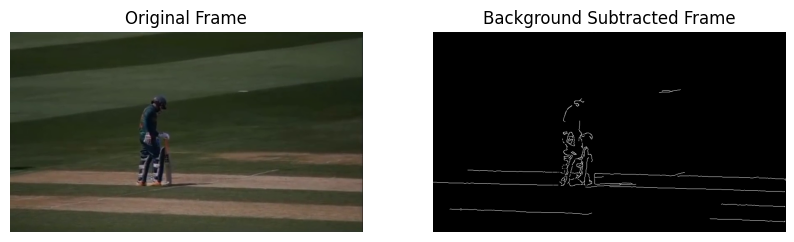

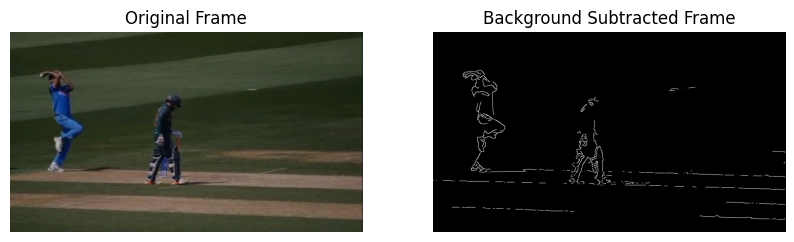

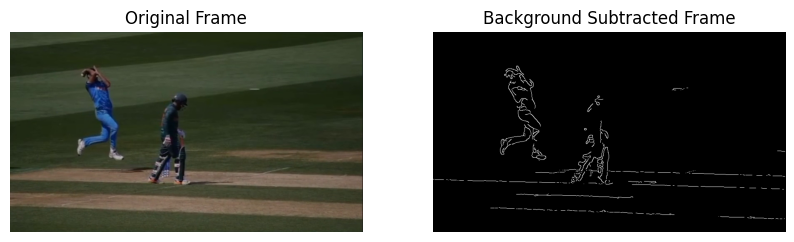

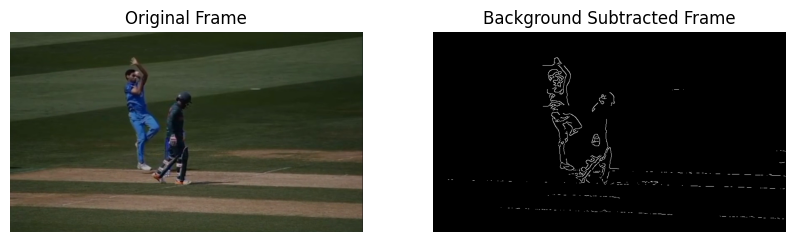

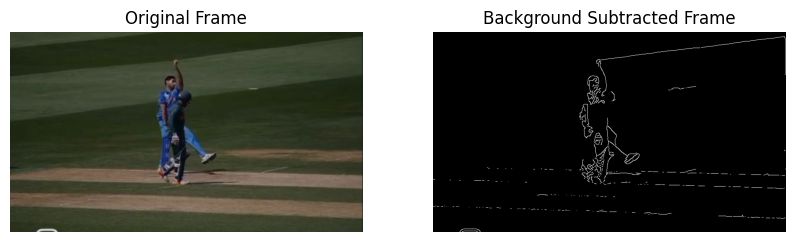

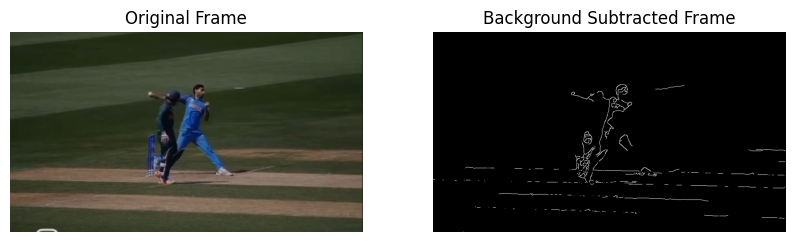

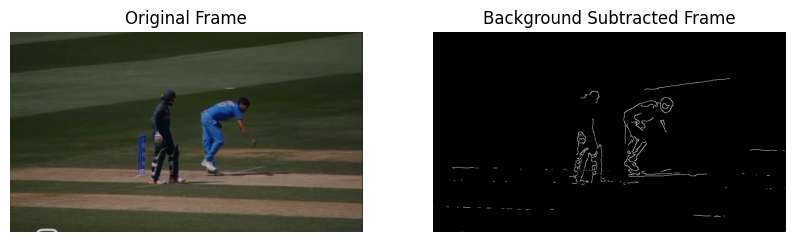

In [13]:
import cv2
import matplotlib.pyplot as plt

vid = cv2.VideoCapture(r"C:\Users\Menaka\Downloads\bhuvi bowling.mp4")

if not vid.isOpened():
    print("Error: Could not open video file")
    exit()

mog2 = cv2.createBackgroundSubtractorMOG2()

fps = int(vid.get(cv2.CAP_PROP_FPS))
frame_interval = int(fps * 2)

frame_count = 0

while vid.isOpened():
    ret, frame = vid.read()
    
    if not ret:
        break
    
    fg = frame.copy()
    frame = cv2.medianBlur(frame, 5)
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    frame = cv2.Canny(frame, 50, 150)
    fg_mask_mog2 = mog2.apply(frame)

    if frame_count % frame_interval == 0:
        plt.figure(figsize=(10, 5))

        plt.subplot(1, 2, 1)
        plt.imshow(cv2.cvtColor(fg, cv2.COLOR_BGR2RGB))  
        plt.title('Original Frame')
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(fg_mask_mog2, cmap='gray')
        plt.title('Background Subtracted Frame')
        plt.axis('off')

        plt.show()

    frame_count += 1

vid.release()


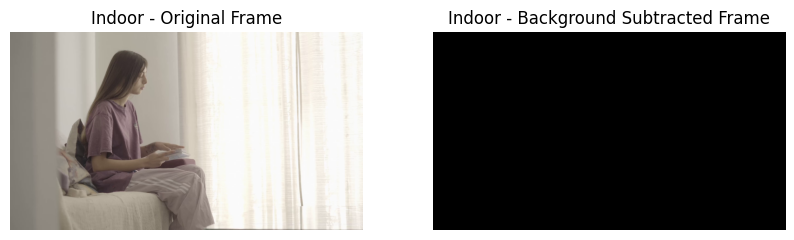

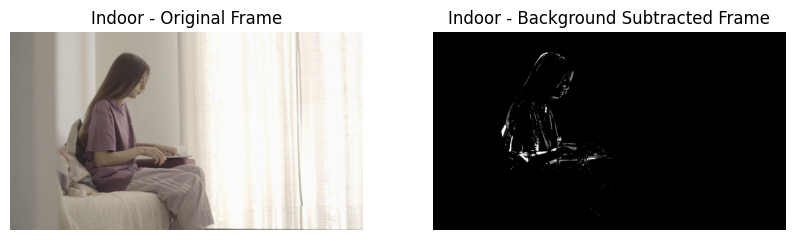

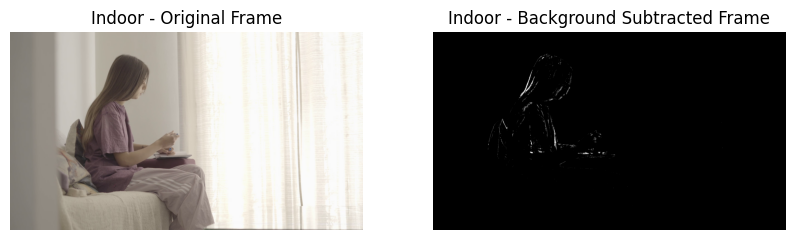

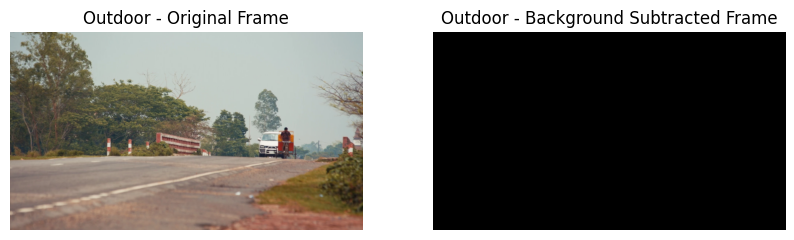

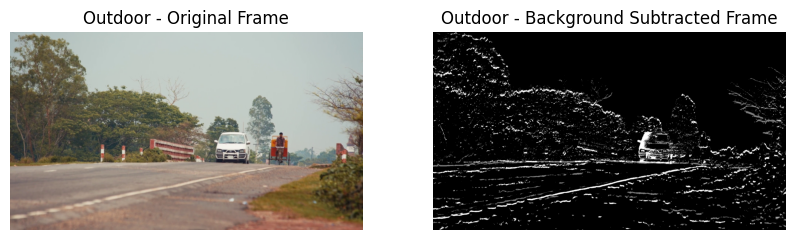

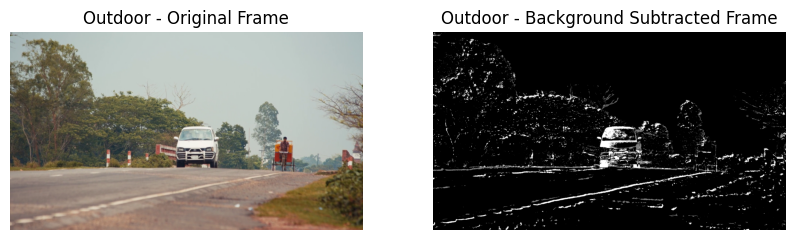

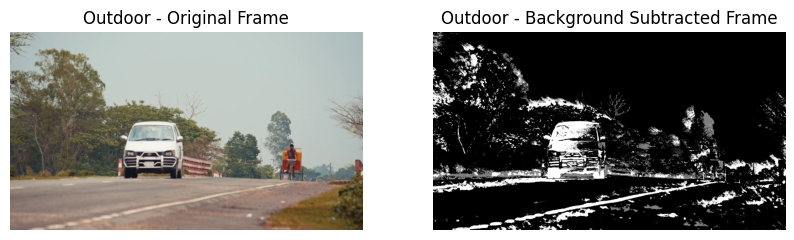

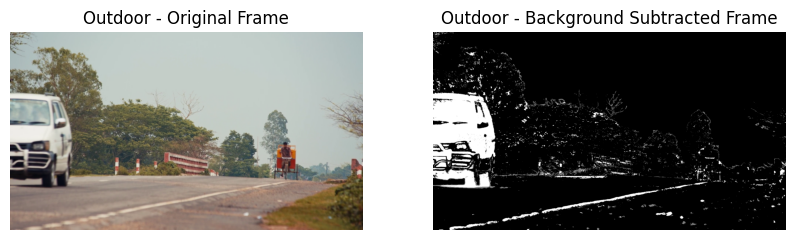

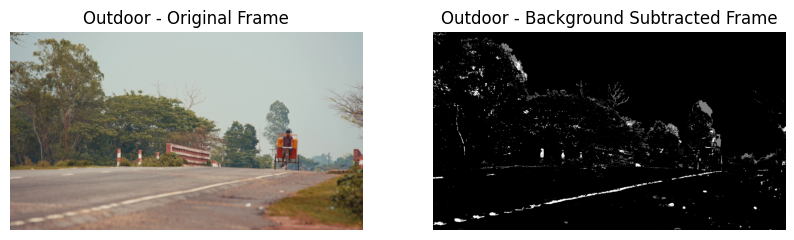

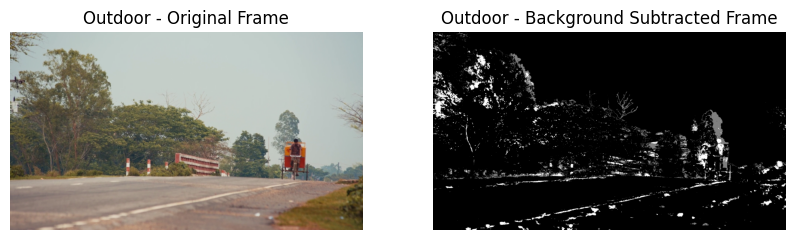

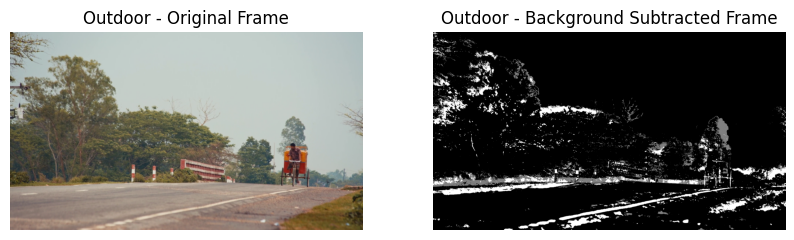

In [25]:
cap_indoor = cv2.VideoCapture(r"C:\Users\Menaka\Downloads\indoor-girl - Trim.mp4")  
cap_outdoor = cv2.VideoCapture(r"C:\Users\Menaka\Downloads\car-moving.mp4")

if not cap_indoor.isOpened() or not cap_outdoor.isOpened():
    print("Error: Could not open one or both video files")
    exit()

mog2_indoor = cv2.createBackgroundSubtractorMOG2()
mog2_outdoor = cv2.createBackgroundSubtractorMOG2()

def process_video(cap, title, mog2):
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    frame_interval = fps * 2  
    frame_count = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        
        fg = frame.copy()
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        fg_mask_mog2 = mog2.apply(frame)

        if frame_count % frame_interval == 0:
            plt.figure(figsize=(10, 5))

            plt.subplot(1, 2, 1)
            plt.imshow(cv2.cvtColor(fg, cv2.COLOR_BGR2RGB))
            plt.title(f'{title} - Original Frame')
            plt.axis('off')

            plt.subplot(1, 2, 2)
            plt.imshow(fg_mask_mog2, cmap='gray')
            plt.title(f'{title} - Background Subtracted Frame')
            plt.axis('off')

            plt.show()

        frame_count += 1

process_video(cap_indoor, "Indoor", mog2_indoor)
process_video(cap_outdoor, "Outdoor", mog2_outdoor)

cap_indoor.release()
cap_outdoor.release()


INDOOR AND OUTDOOR VIDEO

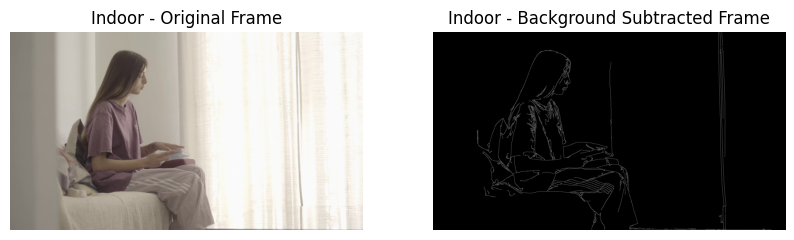

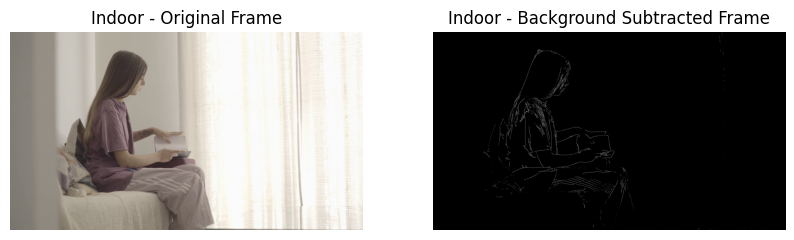

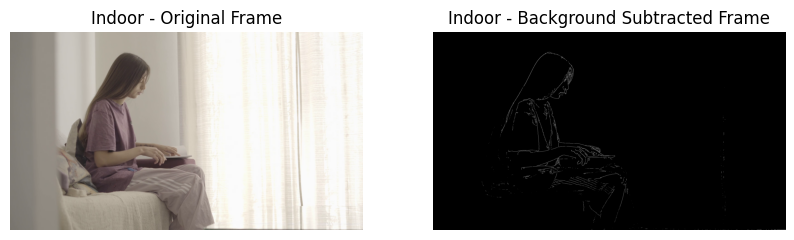

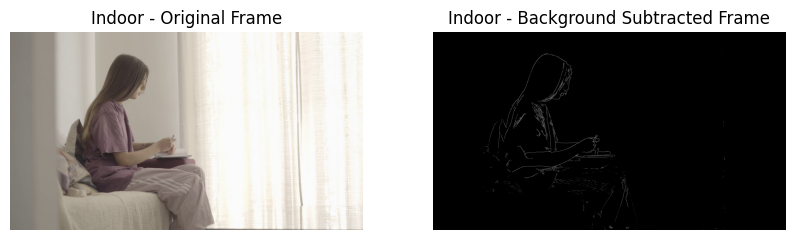

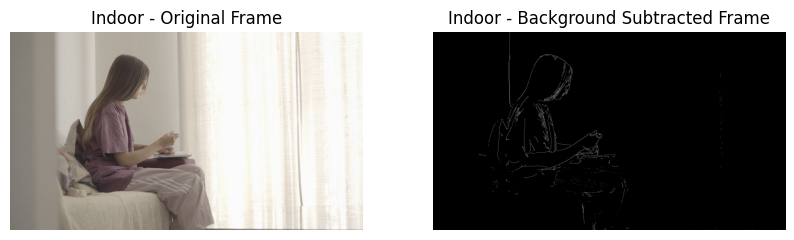

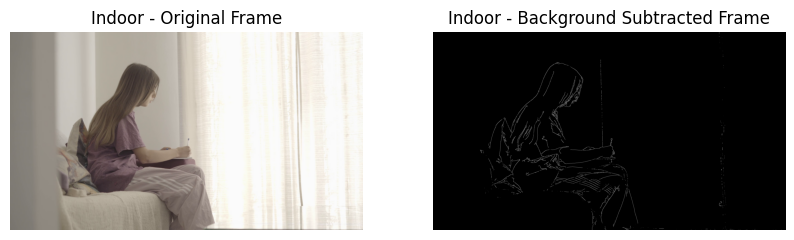

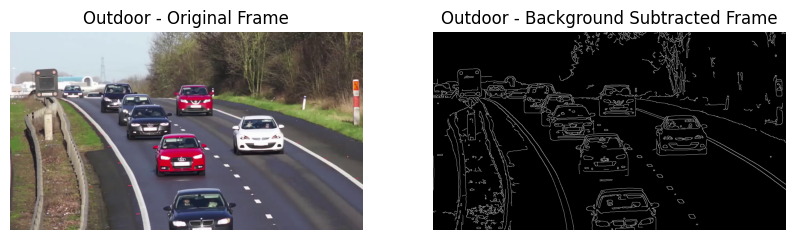

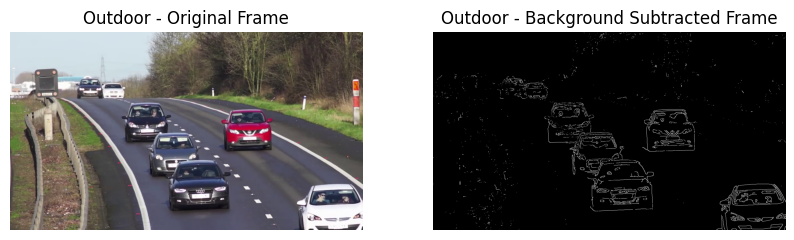

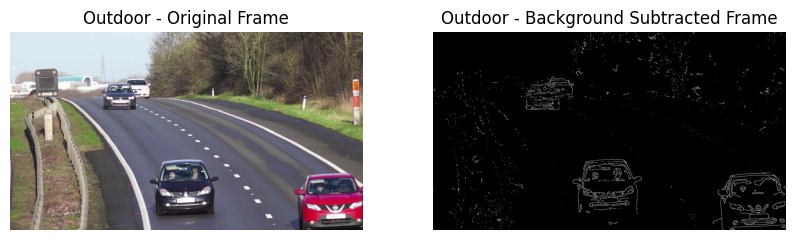

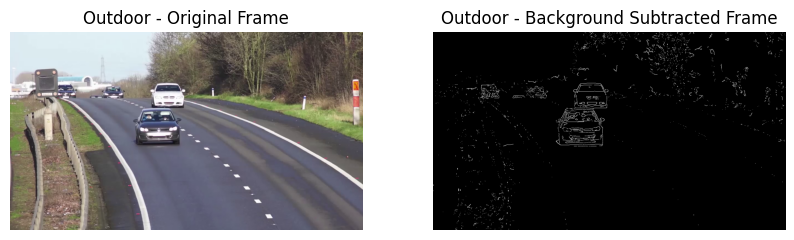

In [24]:
import cv2
import matplotlib.pyplot as plt

cap_indoor = cv2.VideoCapture(r"C:\Users\Menaka\Downloads\indoor-girl - Trim.mp4")  
cap_outdoor = cv2.VideoCapture(r"C:\Users\Menaka\Downloads\cars-outdoor.mp4")

if not cap_indoor.isOpened() or not cap_outdoor.isOpened():
    print("Error: Could not open one or both video files")
    exit()

mog2_indoor = cv2.createBackgroundSubtractorMOG2()
mog2_outdoor = cv2.createBackgroundSubtractorMOG2()

def process_video(cap, title, mog2,thr1,thr2,sec):
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    frame_interval = fps * sec  
    frame_count = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        
        fg = frame.copy()
        frame = cv2.medianBlur(frame, 5)
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frame = cv2.Canny(frame, thr1, thr2)
        frame = cv2.bitwise_not(frame)  
        fg_mask_mog2 = mog2.apply(frame)

        if frame_count % frame_interval == 0:
            plt.figure(figsize=(10, 5))

            plt.subplot(1, 2, 1)
            plt.imshow(cv2.cvtColor(fg, cv2.COLOR_BGR2RGB))
            plt.title(f'{title} - Original Frame')
            plt.axis('off')

            plt.subplot(1, 2, 2)
            plt.imshow(fg_mask_mog2, cmap='gray')
            plt.title(f'{title} - Background Subtracted Frame')
            plt.axis('off')

            plt.show()

        frame_count += 1

process_video(cap_indoor, "Indoor", mog2_indoor,0,100,1)
process_video(cap_outdoor, "Outdoor", mog2_outdoor,50,150,2)

cap_indoor.release()
cap_outdoor.release()


CV2

SCENE CHANGE

In [45]:

bg_subtractor = cv2.createBackgroundSubtractorMOG2(history=500, varThreshold=16, detectShadows=True)

video_path = r"C:\Users\Menaka\Downloads\scene.mp4"  # Change this to the actual video path
cap = cv2.VideoCapture(video_path)

scene_change_threshold = 50000  
prev_foreground = None

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    
    fg_mask = bg_subtractor.apply(frame)
    
    kernel = np.ones((3,3), np.uint8)
    fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_OPEN, kernel)
    fg_mask = cv2.Canny(fg_mask,50,200)
    
    foreground_pixels = np.sum(fg_mask == 255)
    
    if prev_foreground is not None:
        change = abs(foreground_pixels - prev_foreground)
        if change > scene_change_threshold:
            print("Scene Change Detected!")
            cv2.putText(frame, "Scene Change Detected!", (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    
    prev_foreground = foreground_pixels
    
    cv2.imshow("Frame", frame)
    cv2.imshow("Foreground Mask", fg_mask)
    
    if cv2.waitKey(30) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


INDOOR VIDEO

In [35]:

cap = cv2.VideoCapture(r"C:\Users\Menaka\Downloads\indoor-girl - Trim.mp4")

mog2 = cv2.createBackgroundSubtractorMOG2()

thr1, thr2 = 50, 150  

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break  
    frame = cv2.resize(frame,(800,800))

    fg = frame.copy()
    
    frame = cv2.medianBlur(frame, 5)  
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)  
    frame = cv2.Canny(frame, thr1, thr2)  
    frame = cv2.bitwise_not(frame)  

    fg_mask_mog2 = mog2.apply(frame)

    cv2.imshow('Original Video', fg)
    cv2.imshow('Indoor-BG Video', fg_mask_mog2)

    if cv2.waitKey(30) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


OUTDOOR VIDEO

In [40]:

cap = cv2.VideoCapture(r"C:\Users\Menaka\Downloads\cars-outdoor.mp4")

mog2 = cv2.createBackgroundSubtractorMOG2()

thr1, thr2 = 70, 130  

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break  
    frame = cv2.resize(frame,(800,800))

    fg = frame.copy()
    
    frame = cv2.medianBlur(frame, 7)  
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)  
    frame = cv2.Canny(frame, thr1, thr2)  
    frame = cv2.bitwise_not(frame)  

    fg_mask_mog2 = mog2.apply(frame)

    cv2.imshow('Original Video', fg)
    cv2.imshow('Outdoor-BG Video', fg_mask_mog2)

    if cv2.waitKey(30) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
